# ACIS Insurance Risk Analytics: Predictive Modeling

This notebook builds claim-severity models for AlphaCare Insurance Solutions (ACIS).

The goal is to compare Linear Regression, Random Forest, and XGBoost models and determine whether claim severity can be predicted well enough to support risk-based pricing decisions.

## 1. Setup

Import project utilities and modeling dependencies. The reusable functions in `src.modeling` handle preprocessing, missing values, categorical encoding, model training, and evaluation.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data_loader import load_insurance_data, summarize_dataset
from src.model_interpretability import (
    compute_shap_values,
    save_shap_summary_plot,
    shap_feature_importance,
)
from src.modeling import (
    build_linear_model,
    build_pricing_frame,
    build_random_forest_model,
    build_xgboost_model,
    metrics_to_frame,
    predict_claim_probability,
    train_model,
)

RANDOM_STATE = 42
TEST_SIZE = 0.2

sns.set_theme(style="whitegrid", palette="viridis")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:.4f}".format)

## 2. Load Cleaned Data

Use the DVC-generated cleaned dataset from `data/processed/insurance_data_cleaned.csv`.

In [2]:
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "insurance_data_cleaned.csv"

df = load_insurance_data(DATA_PATH)
summarize_dataset(df)

{'rows': 10000,
 'columns': 21,
 'total_cells': 210000,
 'missing_cells': 0,
 'missing_percentage': 0.0,
 'duplicate_rows': 0,
 'duplicate_percentage': 0.0,
 'column_types': {'CustomerID': 'str',
  'Age': 'int64',
  'Gender': 'str',
  'Province': 'str',
  'VehicleType': 'str',
  'AnnualIncome': 'int64',
  'RiskScore': 'int64',
  'AnnualPremium': 'int64',
  'Deductible': 'int64',
  'NCD': 'int64',
  'PastClaims': 'int64',
  'Claimed': 'bool',
  'ClaimAmount': 'float64',
  'TotalPremium': 'int64',
  'TotalClaims': 'float64',
  'CoverType': 'str',
  'AutoMake': 'str',
  'VehicleModel': 'str',
  'CustomValueEstimate': 'int64',
  'ZipCode': 'int64',
  'TransactionDate': 'str'}}

**Business interpretation:** Modeling uses the cleaned, reproducible dataset so model results can be audited and regenerated from the DVC pipeline.

## 3. Define the Severity Modeling Dataset

Claim severity usually means the claim amount for policies that actually had a claim. For this project, `TotalClaims` is used as the severity target, and the modeling dataset is filtered to rows where `TotalClaims > 0`.

This avoids training a severity model that is dominated by zero-claim policies. Claim occurrence can be handled separately as a classification problem.

In [3]:
TARGET_COL = "TotalClaims"

candidate_features = [
    "Age",
    "Gender",
    "Province",
    "VehicleType",
    "AnnualIncome",
    "RiskScore",
    "AnnualPremium",
    "Deductible",
    "NCD",
    "PastClaims",
    "TotalPremium",
    "CoverType",
    "AutoMake",
    "VehicleModel",
    "CustomValueEstimate",
    "ZipCode",
]

feature_cols = [column for column in candidate_features if column in df.columns]
severity_df = df[df[TARGET_COL] > 0].copy()

print(f"Severity modeling rows: {len(severity_df):,}")
print(f"Selected features: {feature_cols}")
severity_df[[TARGET_COL] + feature_cols].head()

Severity modeling rows: 1,535
Selected features: ['Age', 'Gender', 'Province', 'VehicleType', 'AnnualIncome', 'RiskScore', 'AnnualPremium', 'Deductible', 'NCD', 'PastClaims', 'TotalPremium', 'CoverType', 'AutoMake', 'VehicleModel', 'CustomValueEstimate', 'ZipCode']


,TotalClaims,Age,Gender,Province,VehicleType,AnnualIncome,RiskScore,AnnualPremium,Deductible,NCD,PastClaims,TotalPremium,CoverType,AutoMake,VehicleModel,CustomValueEstimate,ZipCode
1,9883.0000,69,Female,Addis Ababa,SUV,74640,57,2334,500,0,4,2334,Comprehensive,Suzuki,Grand Vitara,52510,10001
3,12134.0000,32,Female,Somali,Sedan,89398,63,2370,500,20,0,2370,Comprehensive,Toyota,Corolla,27036,40005
11,3583.0000,28,Male,Tigray,Sedan,95735,67,2655,500,0,0,2655,Third Party Fire & Theft,Lifan,620,27903,50002
21,3974.0000,19,Female,Oromia,SUV,79072,80,2822,500,0,2,2822,Comprehensive,Suzuki,Grand Vitara,45363,20004
26,12791.0000,19,Male,Addis Ababa,Hatchback,56705,95,3551,250,0,2,3551,Comprehensive,Toyota,Vitz,13068,10001


In [4]:
severity_df[TARGET_COL].describe()

count    1535.0000
mean     8561.4886
std      6178.1293
min       924.0000
25%      4480.0000
50%      6968.0000
75%     10746.0000
max     49623.0000
Name: TotalClaims, dtype: float64

**Business interpretation:** The model is trained only on claim records, so the prediction target represents expected claim severity once a claim has occurred. This can support pricing decisions when combined with a separate claim-frequency model.

## 4. Train Linear Regression

Linear Regression provides a simple baseline. It is easy to explain, but it may underperform if claim severity has nonlinear relationships with vehicle, customer, or policy features.

In [5]:
linear_result = train_model(
    severity_df,
    target_col=TARGET_COL,
    model=build_linear_model("regression"),
    feature_cols=feature_cols,
    task_type="regression",
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    scale_numeric=True,
)

linear_metrics = metrics_to_frame(
    "Linear Regression",
    linear_result["metrics"],
    task_type="regression",
)
linear_metrics

,model_name,task_type,mae,rmse,r2
0,Linear Regression,regression,3775.5229,5317.0677,0.2007


## 5. Train Random Forest

Random Forest can capture nonlinear relationships and interactions without requiring heavy feature engineering. It is often a strong benchmark for tabular insurance data.

In [6]:
random_forest_result = train_model(
    severity_df,
    target_col=TARGET_COL,
    model=build_random_forest_model(
        "regression",
        n_estimators=200,
        max_depth=8,
        min_samples_leaf=5,
        n_jobs=-1,
    ),
    feature_cols=feature_cols,
    task_type="regression",
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

random_forest_metrics = metrics_to_frame(
    "Random Forest",
    random_forest_result["metrics"],
    task_type="regression",
)
random_forest_metrics

,model_name,task_type,mae,rmse,r2
0,Random Forest,regression,3794.7528,5292.0870,0.2082


## 6. Train XGBoost

XGBoost is a gradient-boosted tree model that often performs well on structured tabular data. It can capture complex relationships while controlling overfitting through tree depth, learning rate, and regularization.

In [7]:
xgboost_result = train_model(
    severity_df,
    target_col=TARGET_COL,
    model=build_xgboost_model(
        "regression",
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        n_jobs=-1,
    ),
    feature_cols=feature_cols,
    task_type="regression",
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

xgboost_metrics = metrics_to_frame(
    "XGBoost",
    xgboost_result["metrics"],
    task_type="regression",
)
xgboost_metrics

,model_name,task_type,mae,rmse,r2
0,XGBoost,regression,3830.7721,5370.6165,0.1845


## 7. Model Comparison

Compare models using RMSE and R².

- Lower RMSE means smaller average prediction error in claim currency units.
- Higher R² means the model explains more variation in claim severity.

In [8]:
model_comparison = pd.concat(
    [linear_metrics, random_forest_metrics, xgboost_metrics],
    ignore_index=True,
)

model_comparison = model_comparison.sort_values(
    by=["rmse", "r2"],
    ascending=[True, False],
).reset_index(drop=True)

model_comparison

,model_name,task_type,mae,rmse,r2
0,Random Forest,regression,3794.7528,5292.0870,0.2082
1,Linear Regression,regression,3775.5229,5317.0677,0.2007
2,XGBoost,regression,3830.7721,5370.6165,0.1845


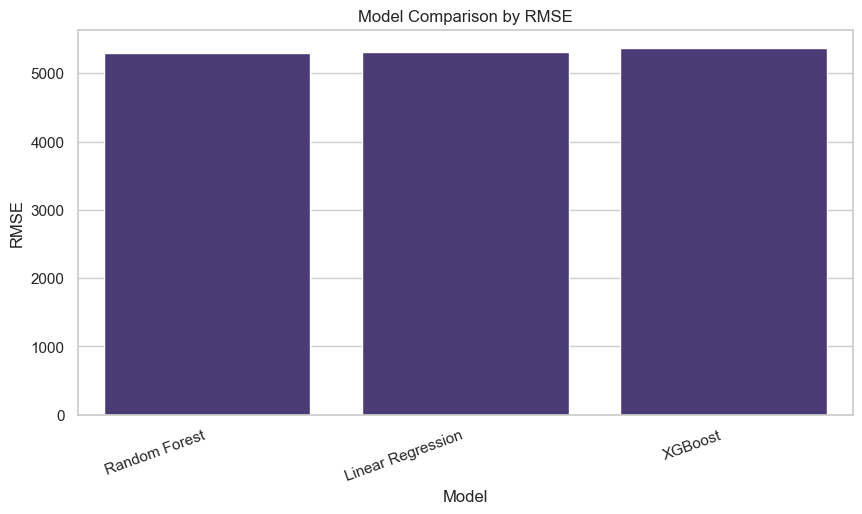

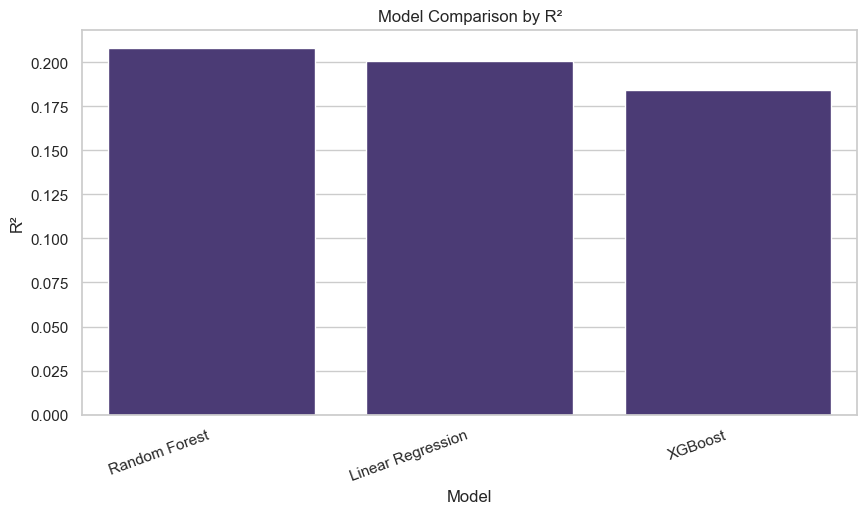

In [9]:
plt.figure(figsize=(10, 5))
sns.barplot(data=model_comparison, x="model_name", y="rmse")
plt.title("Model Comparison by RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=20, ha="right")
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(data=model_comparison, x="model_name", y="r2")
plt.title("Model Comparison by R²")
plt.xlabel("Model")
plt.ylabel("R²")
plt.xticks(rotation=20, ha="right")
plt.show()

In [10]:
best_model_row = model_comparison.iloc[0]
best_model_name = best_model_row["model_name"]

print(
    f"Best model by RMSE: {best_model_name} "
    f"(RMSE={best_model_row['rmse']:.4f}, R²={best_model_row['r2']:.4f})"
)

Best model by RMSE: Random Forest (RMSE=5292.0870, R²=0.2082)


## 8. Which Model Performs Best?

The best model is selected primarily by the lowest RMSE because ACIS needs severity predictions with the smallest claim-amount error. R² is used as a secondary measure to understand how much variation in claim severity the model explains.

If Random Forest or XGBoost performs best, it likely means claim severity depends on nonlinear relationships or interactions between customer, vehicle, policy, and location features. If Linear Regression performs similarly, the simpler model may be preferred because it is easier to explain and audit.

## 9. Business Interpretation

A useful severity model can help ACIS estimate expected claim cost after a claim occurs. This supports risk-based pricing by helping the company understand which policies may require higher premium adequacy.

Important business considerations:

- RMSE should be interpreted in claim-currency units, so lower values mean smaller pricing error.
- A low or negative R² means the current feature set does not explain severity well enough for confident automated pricing.
- Tree-based models may improve predictive power, but ACIS should also review feature importance and regulatory constraints before operational use.
- Severity modeling should be combined with claim-frequency modeling to estimate full expected loss.

## 10. Model Interpretability with SHAP

SHAP explains how each feature contributes to the best model's claim severity predictions. The table below ranks the top features by average absolute SHAP value, which means the features with the largest overall impact on predicted severity appear first.

In [11]:
model_results = {
    "Linear Regression": linear_result,
    "Random Forest": random_forest_result,
    "XGBoost": xgboost_result,
}

best_result = model_results[best_model_name]

shap_values, shap_X = compute_shap_values(
    best_result["model"],
    best_result["X_test"],
    max_rows=500,
    random_state=RANDOM_STATE,
)

top_features = shap_feature_importance(
    shap_values,
    shap_X,
    top_n=10,
)

top_features

,feature,mean_abs_shap,feature_label,business_explanation
2,numeric__RiskScore,1057.4221,RiskScore,`RiskScore` is influential in the model and sh...
7,numeric__TotalPremium,779.1875,TotalPremium,`TotalPremium` reflects pricing or premium lev...
3,numeric__AnnualPremium,603.3393,AnnualPremium,`AnnualPremium` reflects pricing or premium le...
8,numeric__CustomValueEstimate,398.6743,CustomValueEstimate,`CustomValueEstimate` is influential in the mo...
9,numeric__ZipCode,171.2564,ZipCode,`ZipCode` captures location effects. Influence...
1,numeric__AnnualIncome,133.5799,AnnualIncome,`AnnualIncome` captures customer profile infor...
0,numeric__Age,83.5506,Age,`Age` captures customer profile information. I...
4,numeric__Deductible,83.4567,Deductible,`Deductible` captures policy design. Influence...
6,numeric__PastClaims,75.9021,PastClaims,`PastClaims` reflects prior or current claim b...
37,categorical__VehicleModel_RAV4,72.5917,VehicleModel RAV4,`VehicleModel RAV4` captures vehicle character...


In [12]:
REPORTS_DIR = PROJECT_ROOT / "reports"
REPORTS_DIR.mkdir(exist_ok=True)

shap_plot_path = REPORTS_DIR / "shap_summary_claim_severity.png"
save_shap_summary_plot(
    shap_values,
    shap_X,
    shap_plot_path,
    max_display=10,
)

print(f"Saved SHAP summary plot to {shap_plot_path}")

Saved SHAP summary plot to C:\Users\USER\Documents\Projects\10 academy\insurance-risk-analytics-week3\reports\shap_summary_claim_severity.png


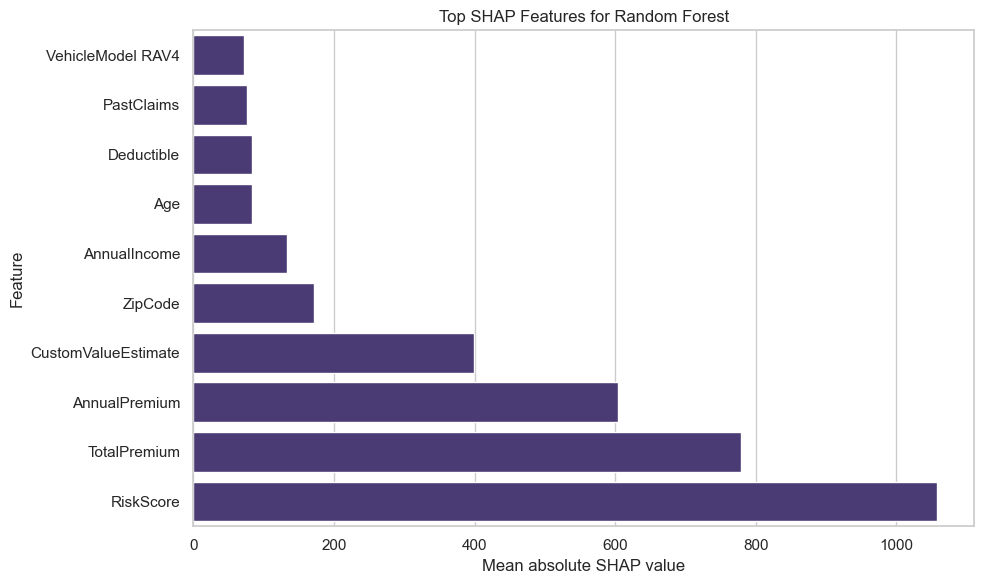

In [13]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_features.sort_values("mean_abs_shap", ascending=True),
    x="mean_abs_shap",
    y="feature_label",
)
plt.title(f"Top SHAP Features for {best_model_name}")
plt.xlabel("Mean absolute SHAP value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

**Business interpretation:** The top SHAP features show which customer, vehicle, policy, and location attributes most influence predicted claim severity. A positive SHAP value increases the predicted claim amount, while a negative SHAP value decreases it. ACIS should use these features to understand pricing drivers, but final pricing decisions should also consider regulatory constraints, fairness, and actuarial review.

## 11. Report-Ready Feature Explanations

The following table is suitable for the final report. It gives the top 5 to 10 influential features and a business-facing explanation of why each feature matters.

In [14]:
report_feature_explanations = top_features[
    ["feature_label", "mean_abs_shap", "business_explanation"]
].rename(
    columns={
        "feature_label": "feature",
        "mean_abs_shap": "importance",
        "business_explanation": "business_interpretation",
    }
)

report_feature_explanations.to_csv(
    REPORTS_DIR / "model_interpretability_top_features.csv",
    index=False,
)

report_feature_explanations

,feature,importance,business_interpretation
2,RiskScore,1057.4221,`RiskScore` is influential in the model and sh...
7,TotalPremium,779.1875,`TotalPremium` reflects pricing or premium lev...
3,AnnualPremium,603.3393,`AnnualPremium` reflects pricing or premium le...
8,CustomValueEstimate,398.6743,`CustomValueEstimate` is influential in the mo...
9,ZipCode,171.2564,`ZipCode` captures location effects. Influence...
1,AnnualIncome,133.5799,`AnnualIncome` captures customer profile infor...
0,Age,83.5506,`Age` captures customer profile information. I...
4,Deductible,83.4567,`Deductible` captures policy design. Influence...
6,PastClaims,75.9021,`PastClaims` reflects prior or current claim b...
37,VehicleModel RAV4,72.5917,`VehicleModel RAV4` captures vehicle character...


## 12. Save Model Comparison Results

Save the model comparison table for reuse in the final report.

In [15]:
REPORTS_DIR = PROJECT_ROOT / "reports"
REPORTS_DIR.mkdir(exist_ok=True)

model_comparison.to_csv(REPORTS_DIR / "model_comparison.csv", index=False)
model_comparison

,model_name,task_type,mae,rmse,r2
0,Random Forest,regression,3794.7528,5292.0870,0.2082
1,Linear Regression,regression,3775.5229,5317.0677,0.2007
2,XGBoost,regression,3830.7721,5370.6165,0.1845


## 13. Next Steps

Recommended next steps for ACIS:

- Add claim-frequency classification to estimate the probability of a claim.
- Combine frequency and severity predictions into expected loss.
- Use SHAP outputs to explain the best model in the final report.
- Validate model stability with cross-validation.
- Review pricing recommendations with business, actuarial, and compliance stakeholders.

## Claim Frequency and Risk-Based Premium Framework

Severity alone is not enough for pricing. ACIS also needs the probability that a policy will claim. The pricing framework combines claim frequency and claim severity:

```text
Pure Premium = P(claim) x Predicted Severity
Technical Premium = Pure Premium + Expense Loading + Risk Load + Profit Margin
```

In [16]:
frequency_df = df.copy()
frequency_df["HasClaim"] = (frequency_df["TotalClaims"] > 0).astype(int)

frequency_result = train_model(
    frequency_df,
    target_col="HasClaim",
    model=build_random_forest_model(
        "classification",
        n_estimators=200,
        max_depth=8,
        min_samples_leaf=5,
        n_jobs=-1,
    ),
    feature_cols=feature_cols,
    task_type="classification",
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

frequency_metrics = metrics_to_frame(
    "Random Forest Claim Frequency",
    frequency_result["metrics"],
    task_type="classification",
)
frequency_metrics

,model_name,task_type,accuracy,precision,recall,f1,roc_auc
0,Random Forest Claim Frequency,classification,0.8570,0.6265,0.1694,0.2667,0.7930


In [17]:
claim_probability = predict_claim_probability(
    frequency_result["model"],
    frequency_result["X_test"],
)

predicted_severity = best_result["model"].predict(frequency_result["X_test"])
predicted_severity = pd.Series(predicted_severity).clip(lower=0)

policy_ids = None
if "CustomerID" in frequency_df.columns:
    policy_ids = frequency_df.loc[frequency_result["X_test"].index, "CustomerID"]

pricing_frame = build_pricing_frame(
    policy_ids=policy_ids,
    claim_probability=claim_probability,
    predicted_severity=predicted_severity,
    expense_loading=0.20,
    risk_loading=0.10,
    profit_margin=0.10,
)

pricing_frame.head()

,policy_id,claim_probability,predicted_severity,pure_premium,technical_premium
0,AC-105763,0.5581,10750.4002,5999.3747,8399.1245
1,AC-106528,0.0665,8597.3735,571.9546,800.7365
2,AC-106791,0.0670,6776.9616,454.1263,635.7768
3,AC-104666,0.0611,5181.9084,316.8318,443.5646
4,AC-109541,0.3112,7374.5726,2294.9125,3212.8775


In [18]:
frequency_metrics.to_csv(REPORTS_DIR / "claim_frequency_model_metrics.csv", index=False)
pricing_frame.to_csv(REPORTS_DIR / "pricing_framework_sample.csv", index=False)

frequency_metrics

,model_name,task_type,accuracy,precision,recall,f1,roc_auc
0,Random Forest Claim Frequency,classification,0.8570,0.6265,0.1694,0.2667,0.7930


**Business interpretation:** This pricing framework separates the chance of a claim from the cost of a claim. ACIS can use it to estimate expected loss, then add expense, risk, and profit loadings to produce a technical premium. The loadings used here are placeholders and should be calibrated by actuarial and finance teams.